# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d

torch.manual_seed(0)

device = 'cuda' ## TODO
torch.set_default_device(device)

### Define the boundary rectangles

In [65]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    bndry = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return bndry

pts_bndry = get_boundary_angled_rectangles()

pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

pts = torch.rand([10000, 3])

bounds = torch.vstack([pts_bndry.min(0).values, pts_bndry.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_bndry.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [66]:
from torch import nn
from torch import tanh

class GeneralNet(nn.Module):
    def __init__(self, ks, act=tanh):
        super(GeneralNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.act = act

    def forward(self, x):
        x = self.fcs[0](x)
        for i in range(2,self.D+1):
            x = self.fcs[i-1](self.act(x))
        return x

In [67]:
from torch.func import vmap, jacrev, jacfwd, functional_call

model = GeneralNet(ks=[3, 32, 32, 1])

params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)

## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_laplacian_f = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
f_theta = jacrev(f, argnums=0)  # dict
vf_theta = vmap(f_theta, in_dims=(None, 0), out_dims=(0))
## Grad Phi (Gradients of Phi wrt x)
phi_x = jacfwd(f_theta, argnums=1)  # dict
v_phi_x = vmap(phi_x, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
laplacian_phi = jacrev(laplacian_f, argnums=0) # dict
v_laplacian_phi = vmap(laplacian_phi, in_dims=(None, 0), out_dims=(0))

### Calculate Hessian approximations

In [68]:
# Approximate Hessians

def calculate_A_interface(params, pts_bndry):
    """
    Calculate the diagonal of boundary integral matrix A_bndry.
    
    Args:
        vf_theta: Function mapping parameters and points to derivatives (jacobian).
        params: Model parameters as a dictionary.
        pts_bndry: Boundary points as a tensor of shape [n_points, n_dims].
        interface_length: Length of the interface for scaling (default: 8).
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the boundary loss [n_params].
    """
    # Compute φ_i at boundary points
    phi_at_pts = vf_theta(params, pts_bndry)  # Returns a dict

    # Aggregate φ_i into a single tensor
    phi_at_pts_tensor = torch.cat([p.flatten(start_dim=1) for p in phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_bndry = torch.einsum('bi,bj->ij', phi_at_pts_tensor, phi_at_pts_tensor) / len(pts_bndry)

    return A_bndry.detach()

def calculate_A_eikonal(params, pts):
    """
    Calculate the diagonal of eikonal integral matrix A_eikonal.
    
    Args:
        v_phi_x: Function mapping parameters and points to gradients of phi (jacobian).
        vf_x: Function mapping parameters and points to gradients of f (jacobian).
        params: Model parameters as a dictionary.
        pts: Points in the space as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the eikonal loss [n_params].
    """
    grad_phi_at_pts = v_phi_x(params, pts)  # Returns a dict
    grad_f_at_pts = vf_x(params, pts)  # Returns a tensor of shape [n_points, 1, n_dims]
    grad_f_at_pts = grad_f_at_pts / (torch.norm(grad_f_at_pts, dim=-1, keepdim=True)+1e-5)

    # Aggregate gradients into a single tensor
    grad_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in grad_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params * n_dims]
    # Reshape to separate the dimensions
    n_points, n_params_times_dims = grad_phi_tensor.shape
    n_dims = pts.shape[1]
    n_params = n_params_times_dims // n_dims
    grad_phi_tensor = grad_phi_tensor.reshape(n_points, n_params, n_dims)  # Shape: [n_points, n_params, n_dims]
    dot_product_term = torch.einsum("bik,bik->i", grad_phi_tensor, grad_f_at_pts)
    A_eikonal = torch.einsum('i,j->ij', dot_product_term, dot_product_term)/n_points
    
    return A_eikonal.detach()


def calculate_A_laplacian(params, pts):
    """
    Calculate the diagonal of Laplacian integral matrix A_laplacian.
    
    Args:
        vf_theta_lap: Function mapping parameters and points to Laplacians (second derivatives).
        params: Model parameters as a dictionary.
        pts: Surface points as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate diagonal of Hessian of the laplacian loss [n_params].
    """
    # Compute Laplacians of φ_i at points
    lap_phi_at_pts = v_laplacian_phi(params, pts)  # Returns a dict
    
    # Aggregate Laplacians into a single tensor
    lap_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in lap_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_laplacian = torch.einsum('bi,bj->ij', lap_phi_tensor, lap_phi_tensor) / len(pts)

    return A_laplacian.detach()

def compute_hessian(params, t):
    """
    Compute the diagonal of the Hessian matrix.
    
    Args:
        params: Model parameters as a dictionary.
        
    Returns:
        torch.Tensor: Diagonal of the Hessian matrix [n_params].
    """
    A = (calculate_A_interface(params, pts_bndry) + 10*calculate_A_interface(params, pts_corners))
    # A = 2 * (calculate_A_interface(params, pts_bndry))
    # A += 2 * (calculate_A_eikonal(params, pts_bndry) + 10*calculate_A_eikonal(params, pts_corners))
    A += 0.01*(calculate_A_eikonal(params, pts_bndry))
    A += calculate_A_laplacian(params, pts)
    return A.detach()

In [69]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
class HandAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        """
        params: iterable of torch.Parameters (e.g. model.parameters())
        lr: learning rate
        betas: (beta1, beta2) coefficients
        eps: small number for numerical stability
        """
        self.params = list(params)  # store references to model parameters
        self.lr = lr
        self.betas = betas
        self.eps = eps

        self.t = 0  # keep track of update steps
        # For each param, maintain its own m (first moment) and v (second moment)
        self.m = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]
        self.v = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]

    def zero_grad(self):
        """Set gradients of all optimized parameters to zero."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        """
        Perform a single Adam update step on all parameters.
        """
        self.t += 1
        beta1, beta2 = self.betas

        for i, param in enumerate(self.params):
            if param.grad is None:
                continue

            g = param.grad  # gradient
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * g      # update first moment
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * (g*g)  # update second moment

            # Correct bias in moments
            m_hat = self.m[i] / (1 - beta1**self.t)
            v_hat = self.v[i] / (1 - beta2**self.t)

            # Update parameter
            param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

class HandGradientDescent:
    def __init__(self, model, lr=1e-3):
        """
        Implements basic gradient descent.
        
        Args:
            params: iterable of torch.Parameters (e.g., model.parameters())
            lr    : learning rate
        """
        self.params_dict = dict(model.named_parameters())
        self.params = list(model.parameters())  # store references to model parameters
        self.lr = lr
        self.t = 0
        # self.A = compute_hessian(self.params_dict, self.t)

    def zero_grad(self):
        """Set gradients of all optimized parameters to zero."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def apply_preconditioner_to_grads(self):
        """
        Solve the least squares problem: x = argmin ||A*x - grads||^2
        and assign the solution back into each parameter's .grad.

        Args:
            params: an iterable of torch.nn.Parameter (those that require gradients).
            A     : a 2D torch.Tensor that matches the dimension of the flattened gradients.
        """
        # 1. Flatten all gradients into a single vector (make sure none are None).
        grads = [p.grad for p in self.params if p.grad is not None]
        flat_grads = parameters_to_vector(grads)  # shape: (N,)
        N = flat_grads.numel()
        # A = torch.eye(N)
        A = compute_hessian(self.params_dict, self.t) + 1e-5*torch.eye(N) #TODO min 1e-2 and loss

        # 2. Solve least squares: x = argmin_x ||A*x - grads||^2
        #    torch.linalg.lstsq returns (solution, residuals, rank, singular_values)
        #    If A is NxN and well-conditioned, this is basically x = (A^T A)^(-1) A^T grads
        x, _, _, _ = torch.linalg.lstsq(A.double(), flat_grads.double(), driver="gels")  # x shape: (*,)

        # 3. Unflatten x back into each parameter’s .grad
        vector_to_parameters(x, grads)

    def step(self):
        """
        Perform a single gradient descent update step on all parameters:
           param.data = param.data - lr * grad
        """
        self.t += 1

        self.apply_preconditioner_to_grads()

        for param in self.params:
            if param.grad is None:
                continue

            # Basic GD update
            param.data -= self.lr * param.grad

In [70]:
pts

tensor([[0.3990, 0.5167, 0.0249],
        [0.9401, 0.9459, 0.7967],
        [0.4150, 0.8203, 0.2290],
        ...,
        [0.1887, 0.5023, 0.2456],
        [0.8373, 0.5556, 0.4048],
        [0.5380, 0.1010, 0.4636]], device='cuda:0')

### Main training loop

  0%|          | 0/10000 [00:00<?, ?it/s]

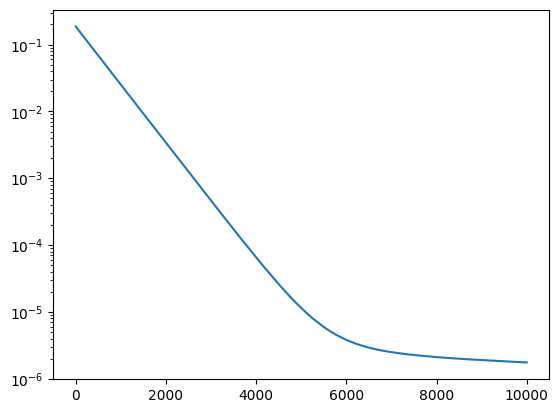

In [71]:
lr_init = 1e-3
# optim = torch.optim.Adam(model.parameters(), lr=lr_init)
optim = HandGradientDescent(model, lr=lr_init)

h_interface, h_eikonal, h_laplacian = 1.0, 0.01, 1.0
# h_eikonal has to be small compared to h_laplace, see StabEik

loss_over_iters = {}

for i in (pbar:=trange(10000)):
    optim.zero_grad()
    params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

    ## 1) Interface at boundaries
    loss_interface  = 0.5*f(params, pts_bndry).square().mean()
    loss_interface += 10*0.5*f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    # loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    laplacian = v_laplacian_f(params, pts).squeeze(1)
    loss_laplacian = 0.5*laplacian.square().mean()
            
   
    loss = h_interface * loss_interface + h_eikonal * loss_eikonal + h_laplacian * loss_laplacian
    loss.backward()
    optim.step()
    # loss = loss.detach()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            # f"curvature: {loss_curvature.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts)}"
                            )
        loss_over_iters[i] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

In [72]:
import sys
sys.path.append('..')
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [73]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

Output()

In [75]:
import torch

# Save the loss dictionary
loss_file = "loss_over_iters_gn.pth"
torch.save(loss_over_iters, loss_file)
print(f"Loss saved to {loss_file}")

# Save the model parameters
model_file = "trained_model_gn.pth"
torch.save(model.state_dict(), model_file)
print(f"Model saved to {model_file}")

Loss saved to loss_over_iters_gn.pth
Model saved to trained_model_gn.pth


In [13]:
# Save the K3D plot as an HTML file
fig_output_file = "k3d_plot_adam.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")


Plot saved to k3d_plot_adam.html


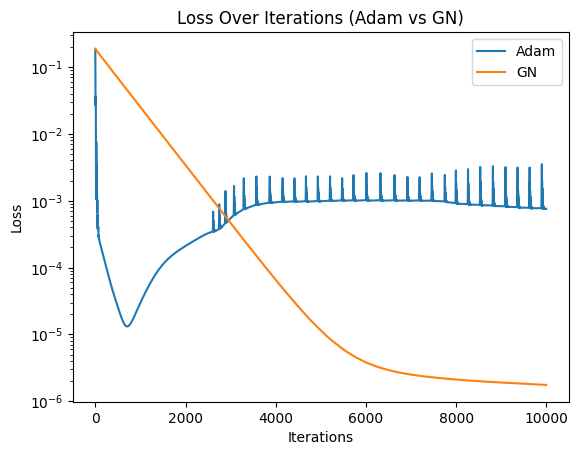

In [76]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_iters_adam.pth")
loss_over_iters_gn = torch.load("loss_over_iters_gn.pth")

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

# Plot both losses
plt.plot(adam_iterations, adam_values, label="Adam")
plt.plot(gn_iterations, gn_values, label="GN")
plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Over Iterations (Adam vs GN)")
plt.legend()
plt.show()
